# YouTube Trending Analysis — 01 Exploratory Data Analysis

An **EDA / visualization** project: engagement on trending YouTube videos — 200k daily stat snapshots of ~11k trending videos (views, likes, dislikes, comments over time). This notebook covers the data overview — shape, types, missing values, and univariate distributions that frame the deeper analysis in notebook 02.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df=utils.load_data()
print('shape:',df.shape)
df.head()

shape: (200000, 7)


,videostatsid,ytvideoid,views,comments,likes,dislikes,timestamp
0,1521476,BccyzhMWVmg,4271393,10699,247354,8581,2020-04-10 20:00:05
1,1141953,3bJFIMcr7NI,777256,2439,33858,371,2020-01-21 04:30:16
2,1203248,pX1puTIogCw,1291478,3509,72360,1315,2020-02-03 05:00:39
3,568283,I82TidwcAYM,174606,269,1802,114,2019-08-03 05:32:48
4,501384,_U2nbcAmgOo,189998,583,8898,161,2019-07-20 04:00:23


## 1. Structure & dtypes

In [2]:
print(df.dtypes.value_counts().to_dict())
df.info()

{dtype('int64'): 5, dtype('O'): 2}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   videostatsid  200000 non-null  int64 
 1   ytvideoid     200000 non-null  object
 2   views         200000 non-null  int64 
 3   comments      200000 non-null  int64 
 4   likes         200000 non-null  int64 
 5   dislikes      200000 non-null  int64 
 6   timestamp     200000 non-null  object
dtypes: int64(5), object(2)
memory usage: 10.7+ MB


## 2. Missing values

In [3]:
mr=utils.missing_report(df)
print('columns with missing values:',len(mr))
print(mr.head(10).to_string())

columns with missing values: 0
Empty DataFrame
Columns: [missing, pct]
Index: []


## 3. Numeric distributions

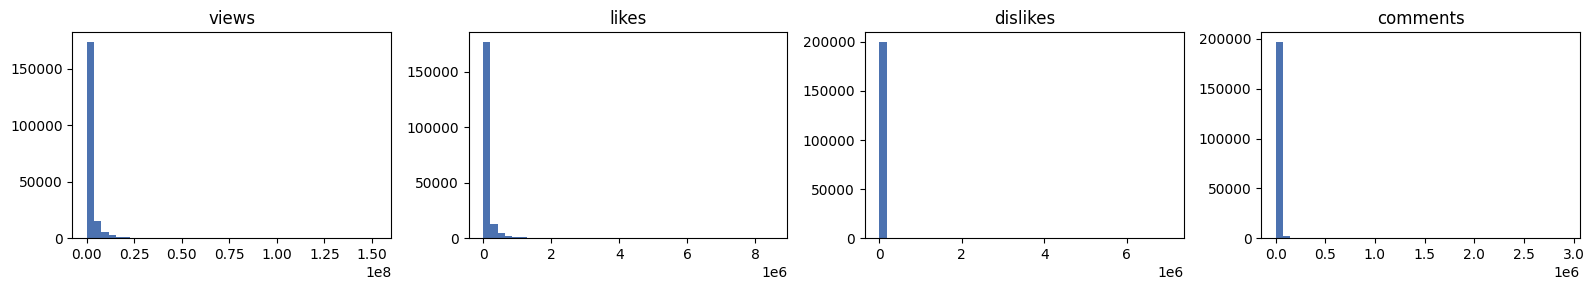

,views,likes,dislikes,comments
count,2.000000e+05,200000.00,200000.00,200000.00
mean,2.330972e+06,113755.11,4497.85,10657.67
std,4.743308e+06,283032.60,72757.90,49488.99
min,3.969000e+03,270.00,6.00,0.00
25%,6.044000e+05,19034.00,471.00,1993.00
50%,1.091419e+06,42757.00,1024.00,4036.00
75%,2.174954e+06,99437.50,2513.00,8888.00
max,1.525982e+08,8516294.00,7026319.00,2918955.00


In [4]:
num=['views', 'likes', 'dislikes', 'comments']
num=[c for c in num if c in df.columns]
fig,ax=plt.subplots(1,len(num),figsize=(4*len(num),3))
ax=np.atleast_1d(ax)
for a,c in zip(ax,num):
    a.hist(df[c].dropna(),bins=40,color='#4c72b0'); a.set_title(c)
plt.tight_layout(); plt.show()
df[num].describe().round(2)

## 4. Top categories

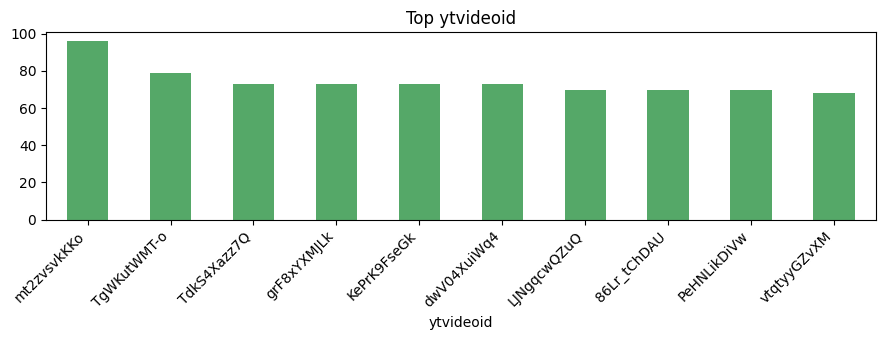

ytvideoid
mt2zvsvkKKo    96
TgWKutWMT-o    79
TdkS4Xazz7Q    73
grF8xYXMJLk    73
KePrK9FseGk    73
dwV04XuiWq4    73
LJNgqcwQZuQ    70
86Lr_tChDAU    70
PeHNLikDiVw    70
vtqtyyGZvXM    68


In [5]:
vc=utils.top_counts(df['ytvideoid'],10)
fig,ax=plt.subplots(figsize=(9,3.5)); vc.plot(kind='bar',ax=ax,color='#55a868'); ax.set_title('Top ytvideoid'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 5. Summary

The overview above frames the domain questions answered in notebook **02 — Analysis**, where the real insights and the headline numbers (reported in the README) come from.